In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score,
    roc_auc_score, roc_curve,
    precision_recall_fscore_support
)
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Global chart style
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'savefig.bbox': 'tight',
    'savefig.dpi': 150
})

PALETTE = {
    'teal':   '#0f766e',
    'purple': '#7c3aed',
    'amber':  '#b45309',
    'red':    '#b91c1c',
    'green':  '#15803d',
    'slate':  '#475569'
}

print('Setup complete.')

Setup complete.


In [4]:
df = pd.read_csv(r'C:\Users\USER\Desktop\iot_p3\smart-garment-storage-environment-condition-monitoring-system\labeled_garment_dataset.csv', encoding='utf-8-sig')
df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True, errors='coerce')
df = df.sort_values('timestamp').reset_index(drop=True)

print(f'Total rows: {len(df):,}')
print(f'Columns ({len(df.columns)}): {list(df.columns)}')
print(f'Date range: {df["timestamp"].min()} → {df["timestamp"].max()}')
print()
print('Warning level distribution:')
print(df['warning_level'].value_counts())
print()
print('Anomaly label distribution:')
print(df['anomaly_label'].value_counts())
df.head(3)

Total rows: 97,458
Columns (33): ['timestamp', 'temperature_c', 'humidity_pct', 'co2_ppm', 'pm25_ug_m3', 'pm10_ug_m3', 'tvoc_ppb', 'co_ppm', 'light_lux', 'motion_detected', 'occupancy_count', 'ventilation_status', 'dust_proxy', 'gas_proxy', 'hour_of_day', 'day_of_week', 'humidity_delta', 'dust_delta', 'gas_delta', 'humidity_pct_roll_mean', 'humidity_pct_roll_std', 'humidity_pct_z', 'dust_proxy_roll_mean', 'dust_proxy_roll_std', 'dust_proxy_z', 'gas_proxy_roll_mean', 'gas_proxy_roll_std', 'gas_proxy_z', 'anomaly_label', 'anomaly_reasons', 'risk_score', 'warning_level', 'storage_health_score']
Date range: 2024-02-18 08:00:00 → 2025-01-22 17:25:00

Warning level distribution:
warning_level
low       65923
medium    31306
high        229
Name: count, dtype: int64

Anomaly label distribution:
anomaly_label
1    87215
0    10243
Name: count, dtype: int64


,timestamp,temperature_c,humidity_pct,co2_ppm,pm25_ug_m3,pm10_ug_m3,tvoc_ppb,co_ppm,light_lux,motion_detected,...,dust_proxy_roll_std,dust_proxy_z,gas_proxy_roll_mean,gas_proxy_roll_std,gas_proxy_z,anomaly_label,anomaly_reasons,risk_score,warning_level,storage_health_score
0,2024-02-18 08:00:00,21.75,63.11,989.74,31.17,89.66,226.83,2.84,646.86,0.0,...,0.0,0.0,0.527427,0.0,0.0,0,normal,0.353202,medium,64.68
1,2024-02-18 08:05:00,27.51,68.03,924.59,27.32,44.82,116.76,3.12,845.45,1.0,...,0.0,0.0,0.527427,0.0,0.0,1,dust_jump,0.467590,medium,53.24
2,2024-02-18 08:10:00,25.32,53.51,604.05,73.84,71.08,56.59,3.59,560.03,1.0,...,0.0,0.0,0.527427,0.0,0.0,1,humidity_jump|dust_jump|gas_jump,0.335721,medium,66.43


In [5]:
ANOMALY_FEATURES = [
    'temperature_c', 'humidity_pct', 'light_lux', 'dust_proxy', 'gas_proxy',
    'humidity_delta', 'dust_delta', 'gas_delta',
    'humidity_pct_z', 'dust_proxy_z', 'gas_proxy_z',
    'humidity_pct_roll_std', 'dust_proxy_roll_std', 'gas_proxy_roll_std',
    'hour_of_day', 'day_of_week'
]

WARNING_FEATURES = ANOMALY_FEATURES + [
    'humidity_pct_roll_mean', 'dust_proxy_roll_mean', 'gas_proxy_roll_mean',
    'anomaly_score_from_pipeline', 'anomaly_flag_from_pipeline'
]

CORR_FEATURES = [
    'temperature_c', 'humidity_pct', 'light_lux', 'dust_proxy', 'gas_proxy',
    'humidity_delta', 'dust_delta', 'gas_delta',
    'humidity_pct_z', 'dust_proxy_z', 'gas_proxy_z',
    'humidity_pct_roll_mean', 'dust_proxy_roll_mean', 'gas_proxy_roll_mean',
    'humidity_pct_roll_std', 'dust_proxy_roll_std', 'gas_proxy_roll_std',
    'anomaly_label'
]

# Drop rows with missing features
df_clean = df.dropna(subset=ANOMALY_FEATURES + ['anomaly_label', 'warning_level']).copy()

# Encode warning level for correlation
wl_map = {'low': 0, 'medium': 1, 'high': 2}
df_clean['warning_level_num'] = df_clean['warning_level'].map(wl_map)

# Chronological split: 70% train, 15% val, 15% test
n = len(df_clean)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

df_train = df_clean.iloc[:train_end].copy()
df_val   = df_clean.iloc[train_end:val_end].copy()
df_test  = df_clean.iloc[val_end:].copy()

print(f'Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')

Train: 68,220 | Val: 14,619 | Test: 14,619


## CHART 1 : Class Distribution (Warning Level & Anomaly Label)



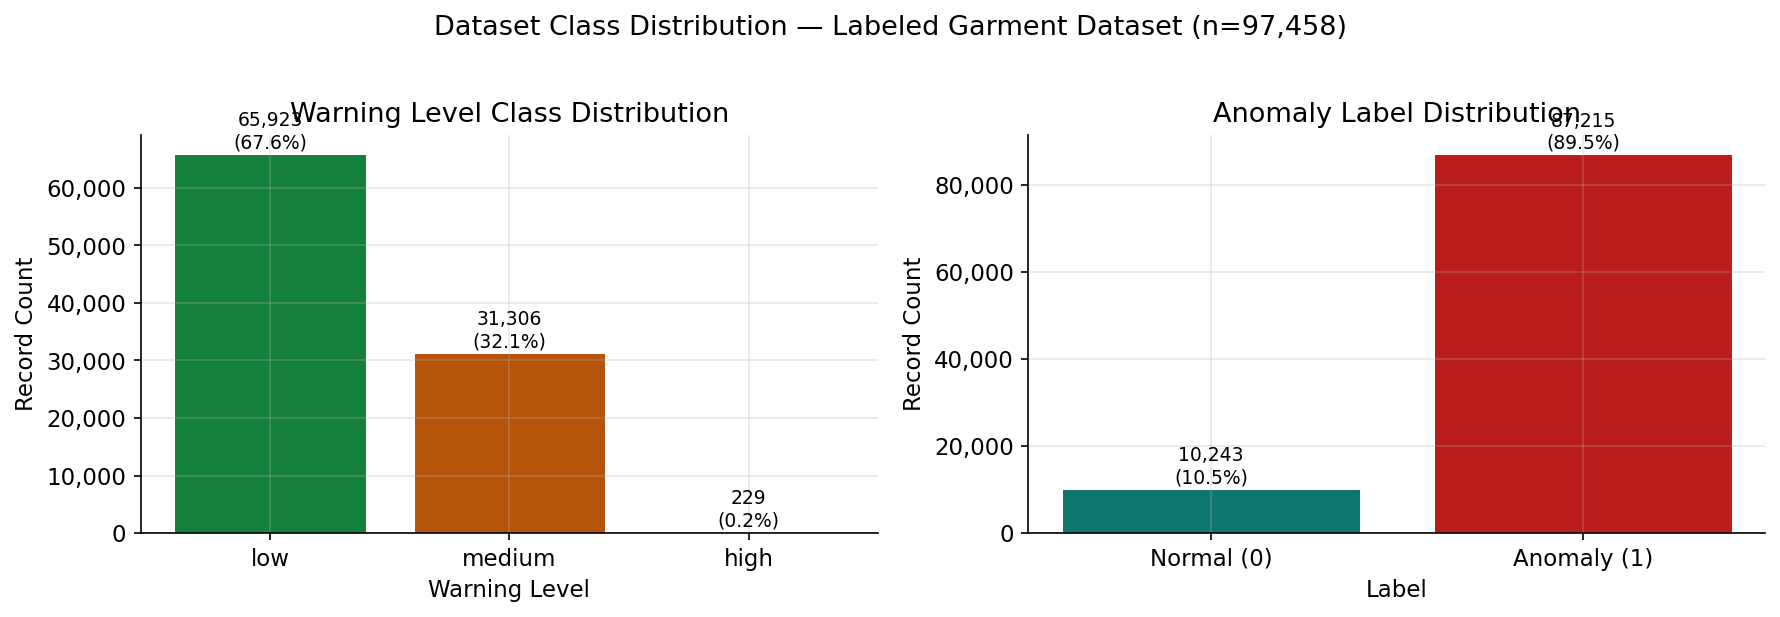

Saved: chart1_class_distribution.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Warning level distribution
wl_counts = df_clean['warning_level'].value_counts().reindex(['low','medium','high'])
colors_wl = [PALETTE['green'], PALETTE['amber'], PALETTE['red']]
bars = axes[0].bar(wl_counts.index, wl_counts.values, color=colors_wl, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, wl_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{val:,}\n({val/len(df_clean)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)
axes[0].set_title('Warning Level Class Distribution')
axes[0].set_xlabel('Warning Level')
axes[0].set_ylabel('Record Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Anomaly label distribution
al_counts = df_clean['anomaly_label'].value_counts().sort_index()
al_labels = ['Normal (0)', 'Anomaly (1)']
al_colors = [PALETTE['teal'], PALETTE['red']]
bars2 = axes[1].bar(al_labels, al_counts.values, color=al_colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars2, al_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{val:,}\n({val/len(df_clean)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)
axes[1].set_title('Anomaly Label Distribution')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Record Count')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Dataset Class Distribution — Labeled Garment Dataset (n=97,458)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('chart1_class_distribution.png')
plt.show()
print('Saved: chart1_class_distribution.png')

---
## CHART 2 : Anomaly Reasons Bar Chart

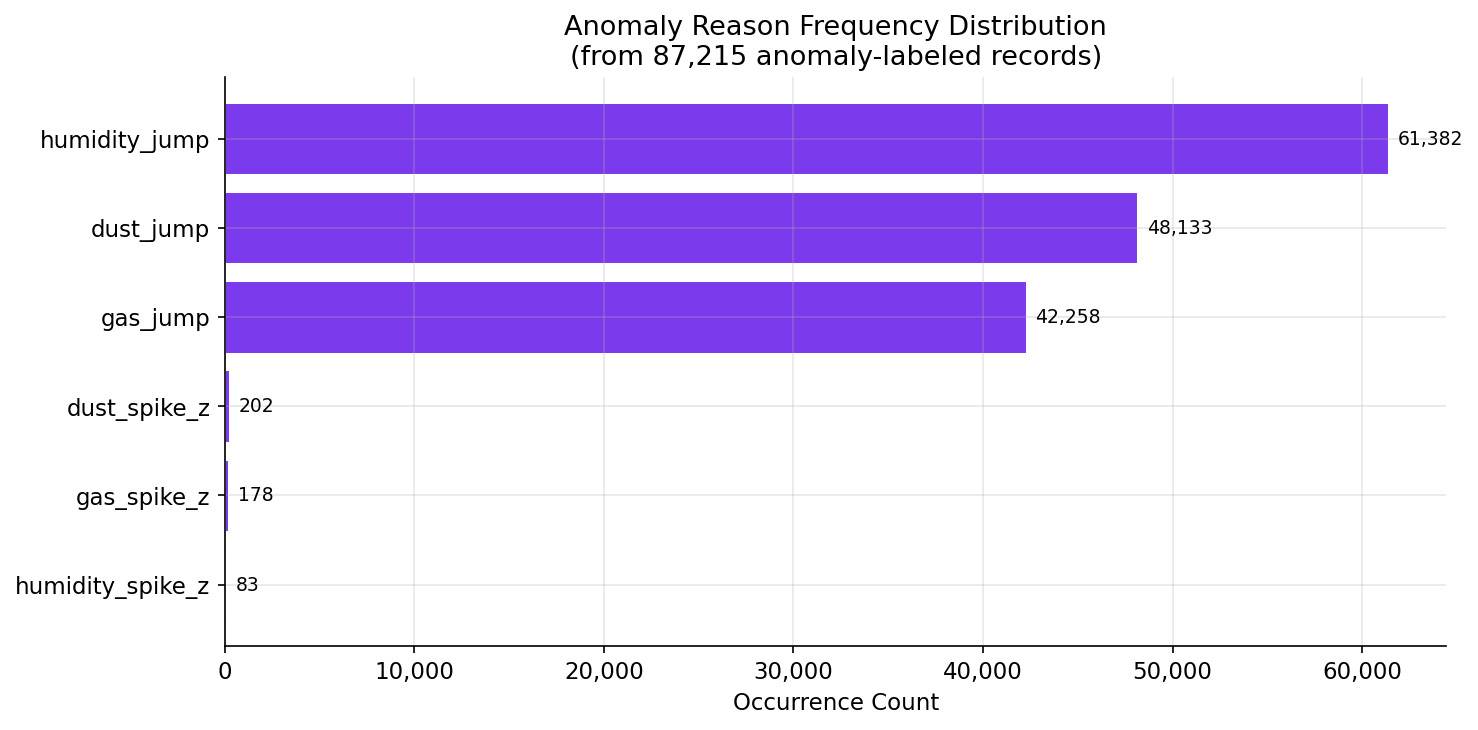

Saved: chart2_anomaly_reasons.png


In [7]:
reasons_flat = []
for val in df_clean['anomaly_reasons'].dropna():
    if val not in ('normal', '0', ''):
        for r in str(val).split('|'):
            r = r.strip()
            if r:
                reasons_flat.append(r)

from collections import Counter
reason_counts = Counter(reasons_flat)
reasons_df = pd.DataFrame(reason_counts.most_common(), columns=['Reason', 'Count'])

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(reasons_df['Reason'], reasons_df['Count'],
               color=PALETTE['purple'], edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, reasons_df['Count']):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.set_xlabel('Occurrence Count')
ax.set_title('Anomaly Reason Frequency Distribution\n(from 87,215 anomaly-labeled records)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('chart2_anomaly_reasons.png')
plt.show()
print('Saved: chart2_anomaly_reasons.png')

---
## CHART 3 : Correlation Heatmap

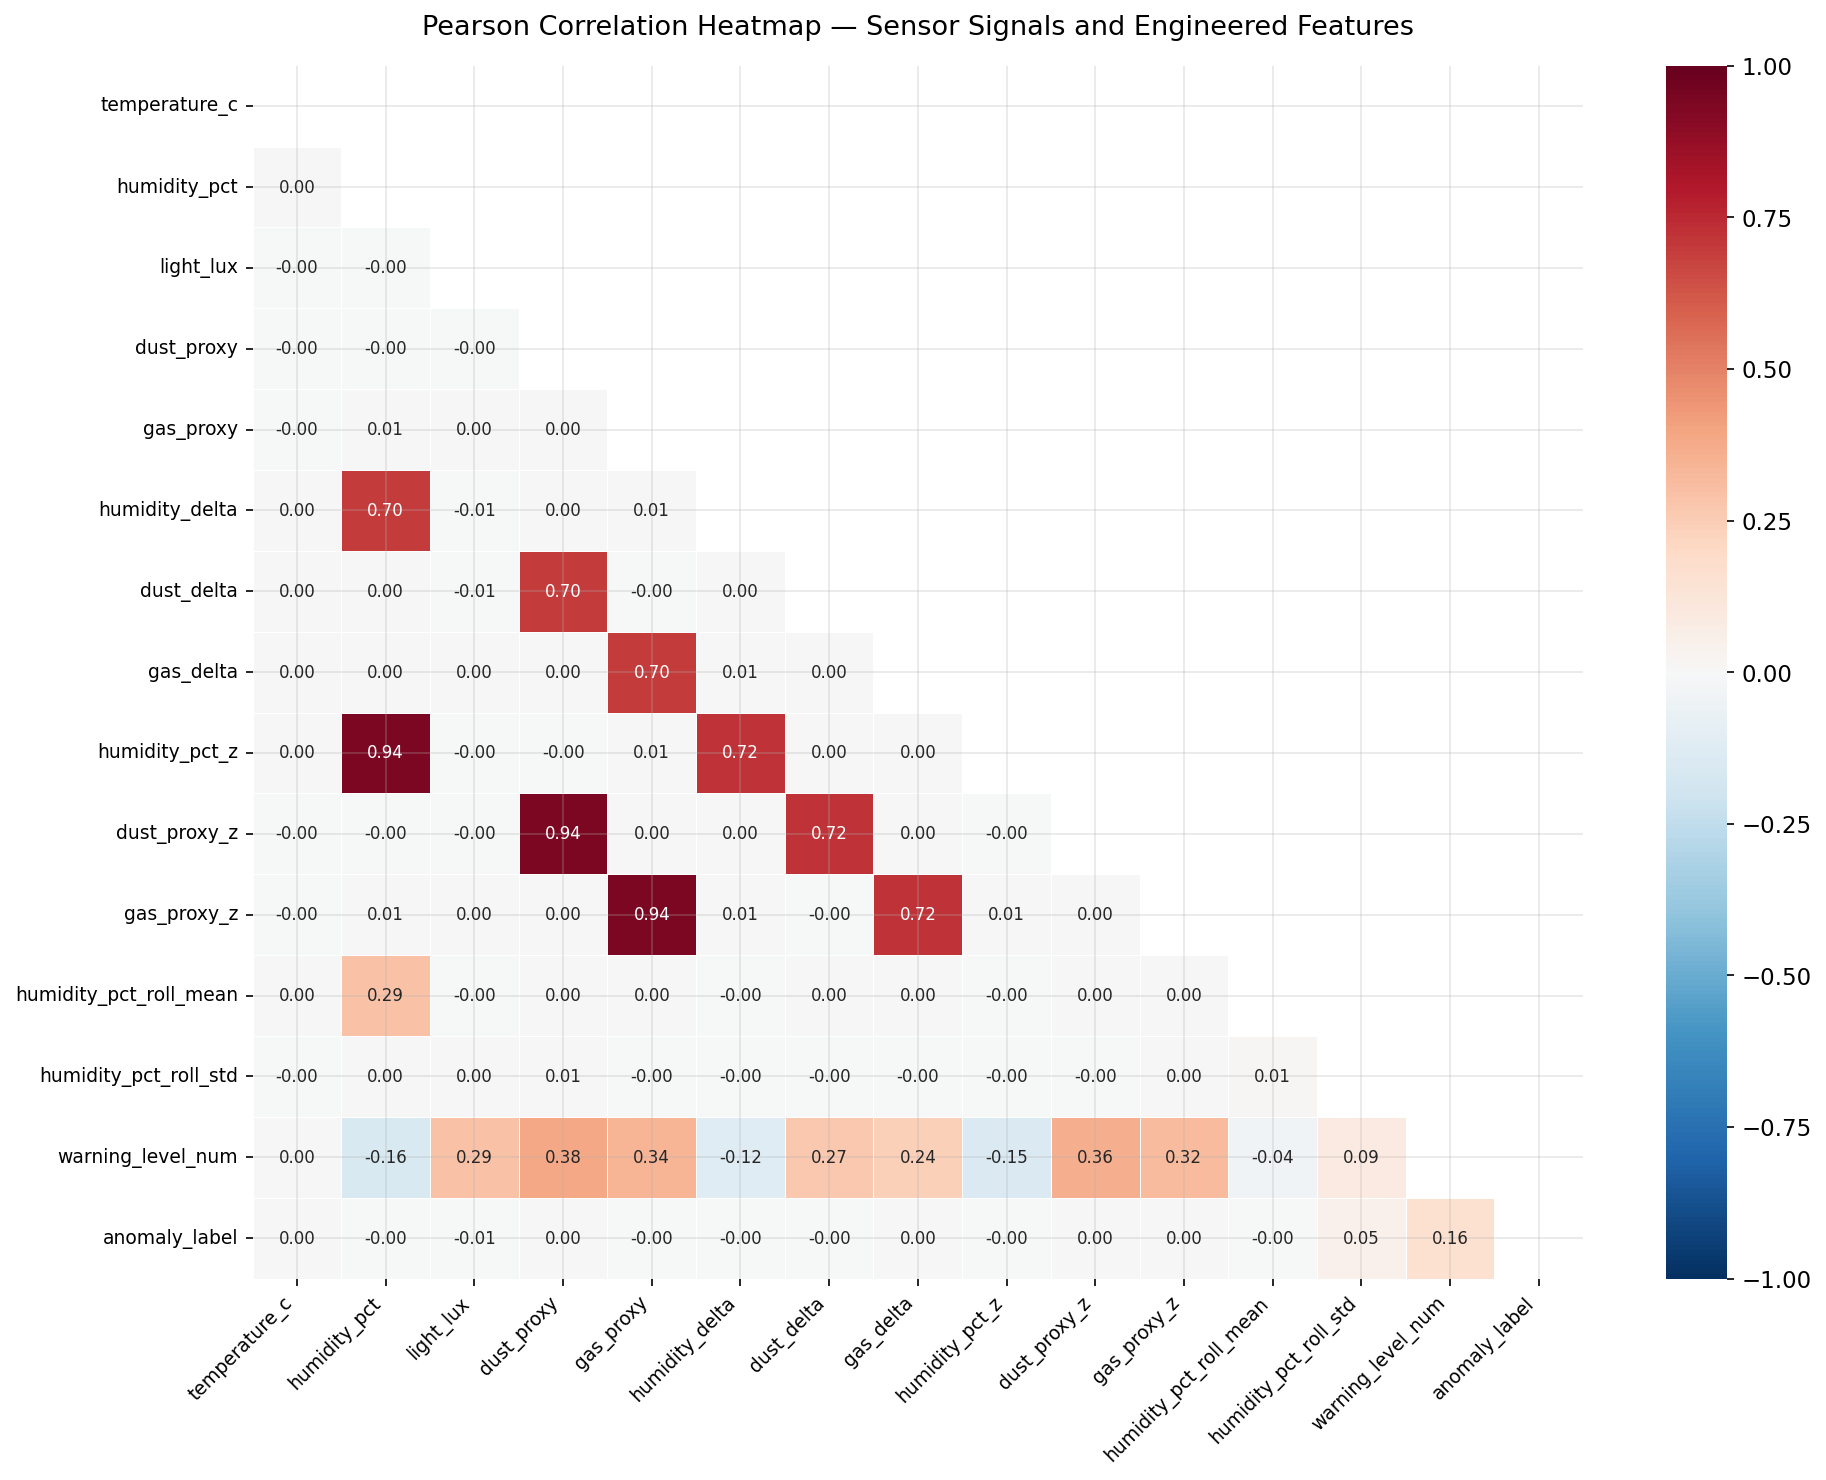

Saved: chart3_correlation_heatmap.png


In [8]:
corr_cols = [
    'temperature_c', 'humidity_pct', 'light_lux', 'dust_proxy', 'gas_proxy',
    'humidity_delta', 'dust_delta', 'gas_delta',
    'humidity_pct_z', 'dust_proxy_z', 'gas_proxy_z',
    'humidity_pct_roll_mean', 'humidity_pct_roll_std',
    'warning_level_num', 'anomaly_label'
]
existing_cols = [c for c in corr_cols if c in df_clean.columns]
corr_matrix = df_clean[existing_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, linecolor='white',
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Pearson Correlation Heatmap — Sensor Signals and Engineered Features', fontsize=13, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('chart3_correlation_heatmap.png')
plt.show()
print('Saved: chart3_correlation_heatmap.png')

---
## CHART 4 : Isolation Forest: Train and Evaluate Anomaly Detection

In [9]:
# Train Isolation Forest
scaler_if = StandardScaler()
X_train_if = scaler_if.fit_transform(df_train[ANOMALY_FEATURES].astype(float))
X_test_if  = scaler_if.transform(df_test[ANOMALY_FEATURES].astype(float))

contamination = float(np.clip(df_train['anomaly_label'].mean(), 0.02, 0.35))
iso_forest = IsolationForest(n_estimators=250, contamination=contamination, random_state=42)
iso_forest.fit(X_train_if)

# Compute normalized scores
train_raw = -iso_forest.decision_function(X_train_if)
score_min, score_max = train_raw.min(), train_raw.max()
denom = score_max - score_min or 1.0

test_raw    = -iso_forest.decision_function(X_test_if)
test_scores = np.clip((test_raw - score_min) / denom, 0, 1)

# Threshold tuning on validation set
X_val_if = scaler_if.transform(df_val[ANOMALY_FEATURES].astype(float))
val_raw  = -iso_forest.decision_function(X_val_if)
val_scores = np.clip((val_raw - score_min) / denom, 0, 1)
val_labels = df_val['anomaly_label'].to_numpy(dtype=int)

thresholds = np.linspace(0.2, 0.9, 29)
f1_scores = []
for t in thresholds:
    preds = (val_scores >= t).astype(int)
    f1_scores.append(f1_score(val_labels, preds, zero_division=0))

best_idx = int(np.argmax(f1_scores))
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f'Best threshold: {best_threshold:.3f} | Best F1: {best_f1:.4f}')

# Final predictions on test set
y_true_if = df_test['anomaly_label'].to_numpy(dtype=int)
y_pred_if = (test_scores >= best_threshold).astype(int)

Best threshold: 0.200 | Best F1: 0.8989


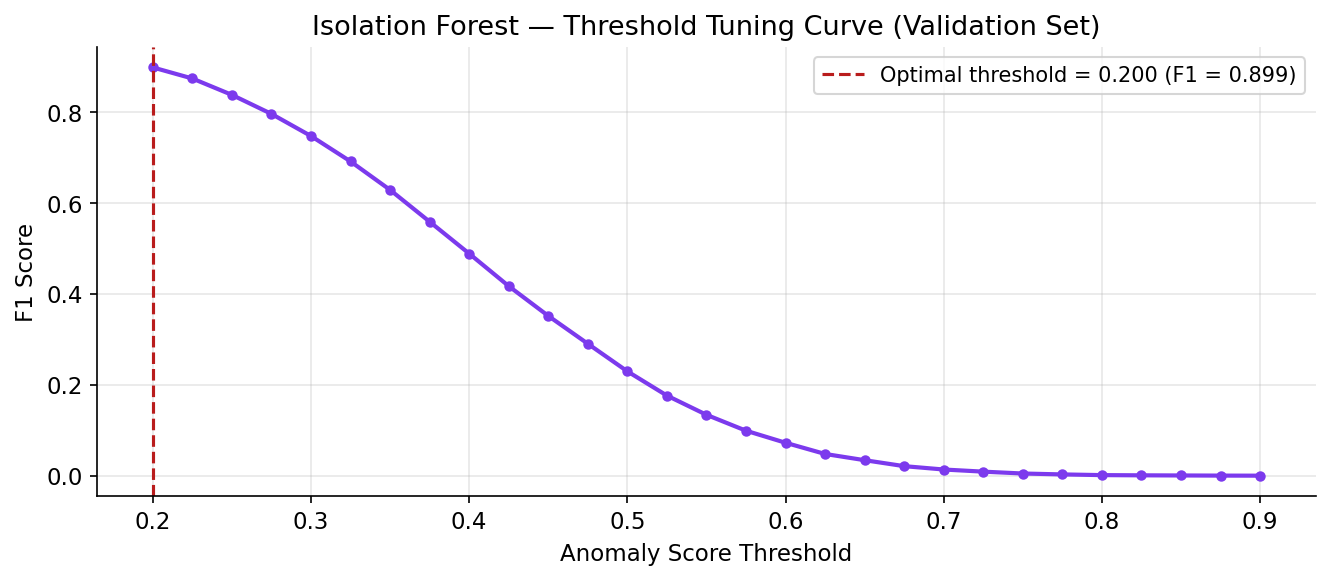

Saved: chart4a_threshold_tuning.png


In [10]:
# CHART 4a — Threshold tuning curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1_scores, color=PALETTE['purple'], linewidth=2, marker='o', markersize=4)
ax.axvline(best_threshold, color=PALETTE['red'], linestyle='--', linewidth=1.5,
           label=f'Optimal threshold = {best_threshold:.3f} (F1 = {best_f1:.3f})')
ax.set_xlabel('Anomaly Score Threshold')
ax.set_ylabel('F1 Score')
ax.set_title('Isolation Forest — Threshold Tuning Curve (Validation Set)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('chart4a_threshold_tuning.png')
plt.show()
print('Saved: chart4a_threshold_tuning.png')

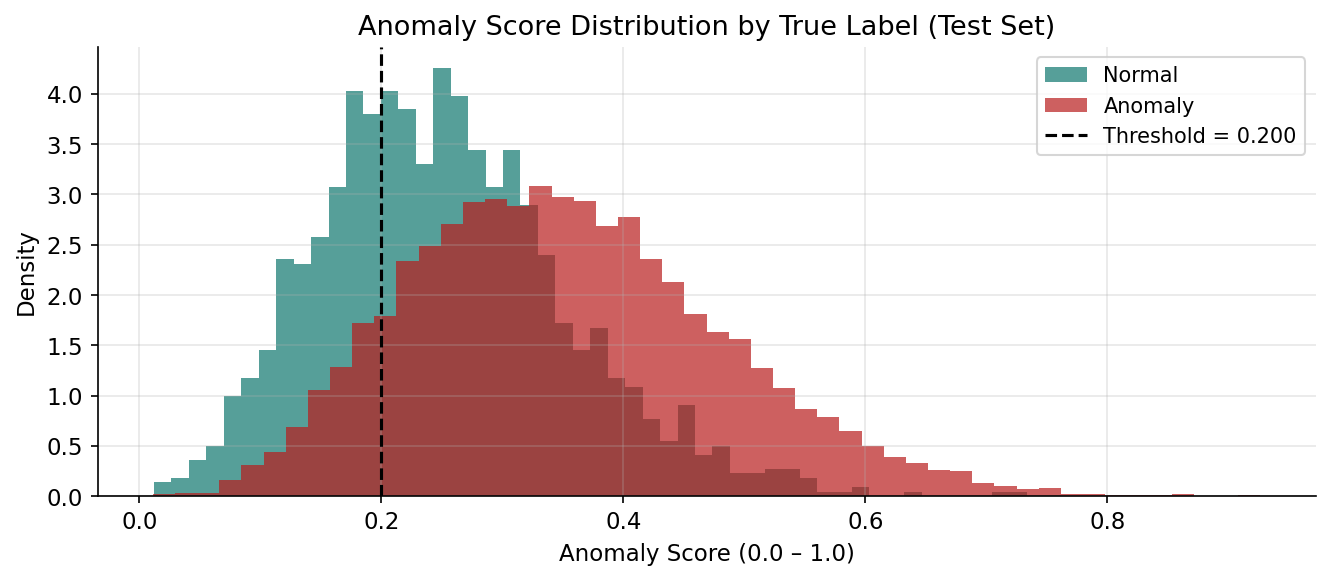

Saved: chart4b_anomaly_score_distribution.png


In [11]:
# CHART 4b — Anomaly Score Distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(test_scores[y_true_if == 0], bins=50, alpha=0.7,
        color=PALETTE['teal'], label='Normal', density=True)
ax.hist(test_scores[y_true_if == 1], bins=50, alpha=0.7,
        color=PALETTE['red'], label='Anomaly', density=True)
ax.axvline(best_threshold, color='black', linestyle='--', linewidth=1.5,
           label=f'Threshold = {best_threshold:.3f}')
ax.set_xlabel('Anomaly Score (0.0 – 1.0)')
ax.set_ylabel('Density')
ax.set_title('Anomaly Score Distribution by True Label (Test Set)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('chart4b_anomaly_score_distribution.png')
plt.show()
print('Saved: chart4b_anomaly_score_distribution.png')

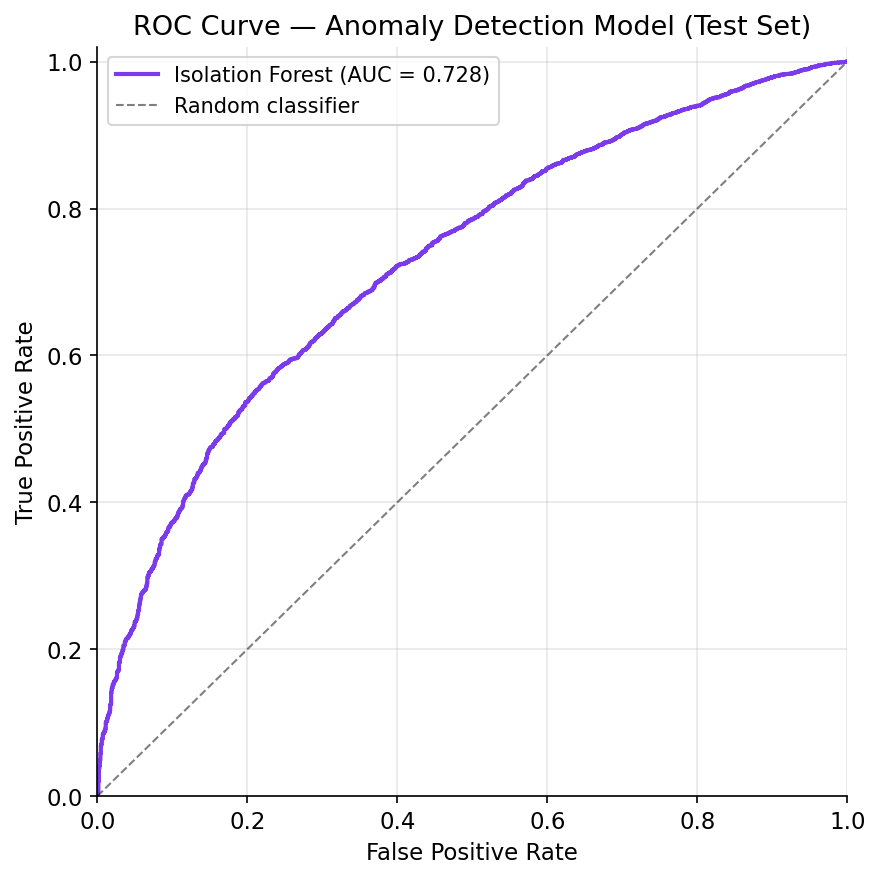

AUC: 0.7282
Saved: chart4c_roc_curve.png


In [12]:
# CHART 4c — ROC Curve
fpr, tpr, _ = roc_curve(y_true_if, test_scores)
auc_score = roc_auc_score(y_true_if, test_scores)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color=PALETTE['purple'], linewidth=2,
        label=f'Isolation Forest (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Anomaly Detection Model (Test Set)')
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('chart4c_roc_curve.png')
plt.show()
print(f'AUC: {auc_score:.4f}')
print('Saved: chart4c_roc_curve.png')

---
## CHART 5 : Random Forest: Warning Level Classification

In [13]:
# Add chained anomaly features from Isolation Forest output
def add_anomaly_pipeline_features(df_split, scaler, model, score_min, denom, threshold):
    avail = [f for f in ANOMALY_FEATURES if f in df_split.columns]
    X = scaler.transform(df_split[avail].astype(float))
    raw = -model.decision_function(X)
    scores = np.clip((raw - score_min) / denom, 0, 1)
    df_split = df_split.copy()
    df_split['anomaly_score_from_pipeline'] = scores
    df_split['anomaly_flag_from_pipeline']  = (scores >= threshold).astype(int)
    return df_split

df_train_rf = add_anomaly_pipeline_features(df_train, scaler_if, iso_forest, score_min, denom, best_threshold)
df_val_rf   = add_anomaly_pipeline_features(df_val,   scaler_if, iso_forest, score_min, denom, best_threshold)
df_test_rf  = add_anomaly_pipeline_features(df_test,  scaler_if, iso_forest, score_min, denom, best_threshold)

wf_cols = [f for f in WARNING_FEATURES if f in df_train_rf.columns]

X_train_rf = df_train_rf[wf_cols].astype(float)
y_train_rf = df_train_rf['warning_level']
X_test_rf  = df_test_rf[wf_cols].astype(float)
y_test_rf  = df_test_rf['warning_level']

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_rf, y_train_rf)
y_pred_rf = rf.predict(X_test_rf)

print(classification_report(y_test_rf, y_pred_rf, target_names=['high','low','medium']))

              precision    recall  f1-score   support

        high       1.00      0.16      0.27        32
         low       0.96      0.98      0.97      9941
      medium       0.94      0.92      0.93      4646

    accuracy                           0.96     14619
   macro avg       0.97      0.68      0.72     14619
weighted avg       0.96      0.96      0.96     14619



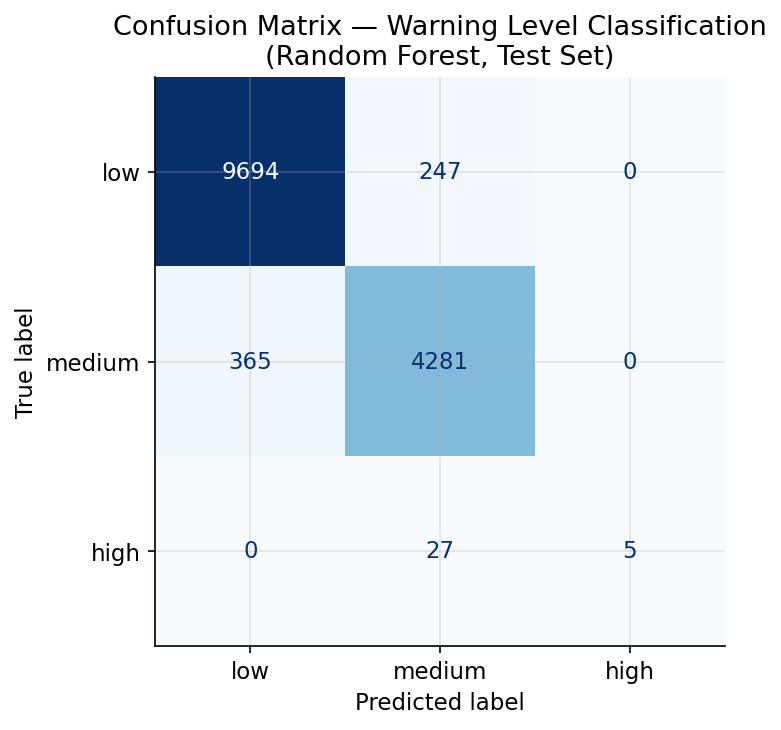

Saved: chart5a_confusion_matrix.png


In [14]:
# CHART 5a — Confusion Matrix
labels_order = ['low', 'medium', 'high']
cm = confusion_matrix(y_test_rf, y_pred_rf, labels=labels_order)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Warning Level Classification\n(Random Forest, Test Set)')
plt.tight_layout()
plt.savefig('chart5a_confusion_matrix.png')
plt.show()
print('Saved: chart5a_confusion_matrix.png')

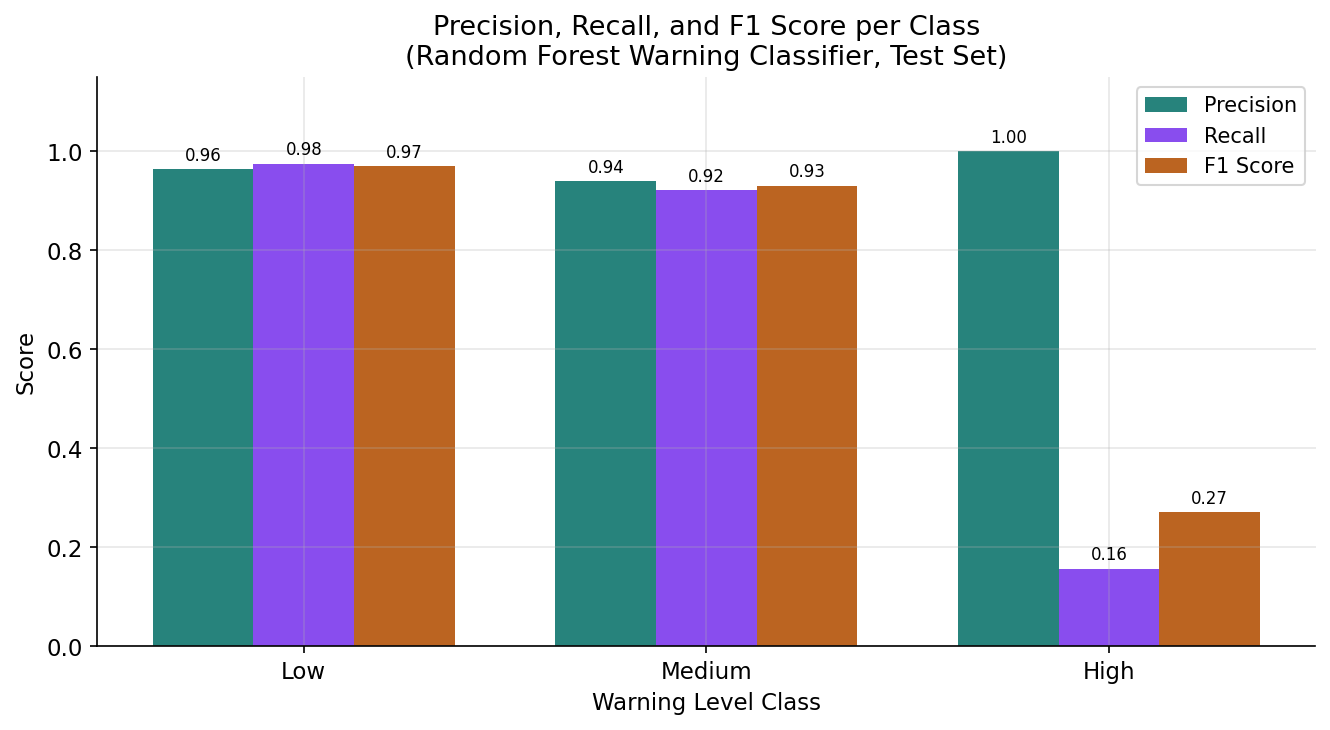

Saved: chart5b_precision_recall_f1.png


In [15]:
# CHART 5b — Precision, Recall, F1 per class
p, r, f, s = precision_recall_fscore_support(
    y_test_rf, y_pred_rf, labels=['low','medium','high'], zero_division=0
)
x = np.arange(3)
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, p, width, label='Precision', color=PALETTE['teal'],   alpha=0.9)
ax.bar(x,         r, width, label='Recall',    color=PALETTE['purple'], alpha=0.9)
ax.bar(x + width, f, width, label='F1 Score',  color=PALETTE['amber'],  alpha=0.9)

for i, (pv, rv, fv) in enumerate(zip(p, r, f)):
    ax.text(i - width, pv + 0.01, f'{pv:.2f}', ha='center', va='bottom', fontsize=8)
    ax.text(i,         rv + 0.01, f'{rv:.2f}', ha='center', va='bottom', fontsize=8)
    ax.text(i + width, fv + 0.01, f'{fv:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(['Low', 'Medium', 'High'])
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_xlabel('Warning Level Class')
ax.set_title('Precision, Recall, and F1 Score per Class\n(Random Forest Warning Classifier, Test Set)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('chart5b_precision_recall_f1.png')
plt.show()
print('Saved: chart5b_precision_recall_f1.png')

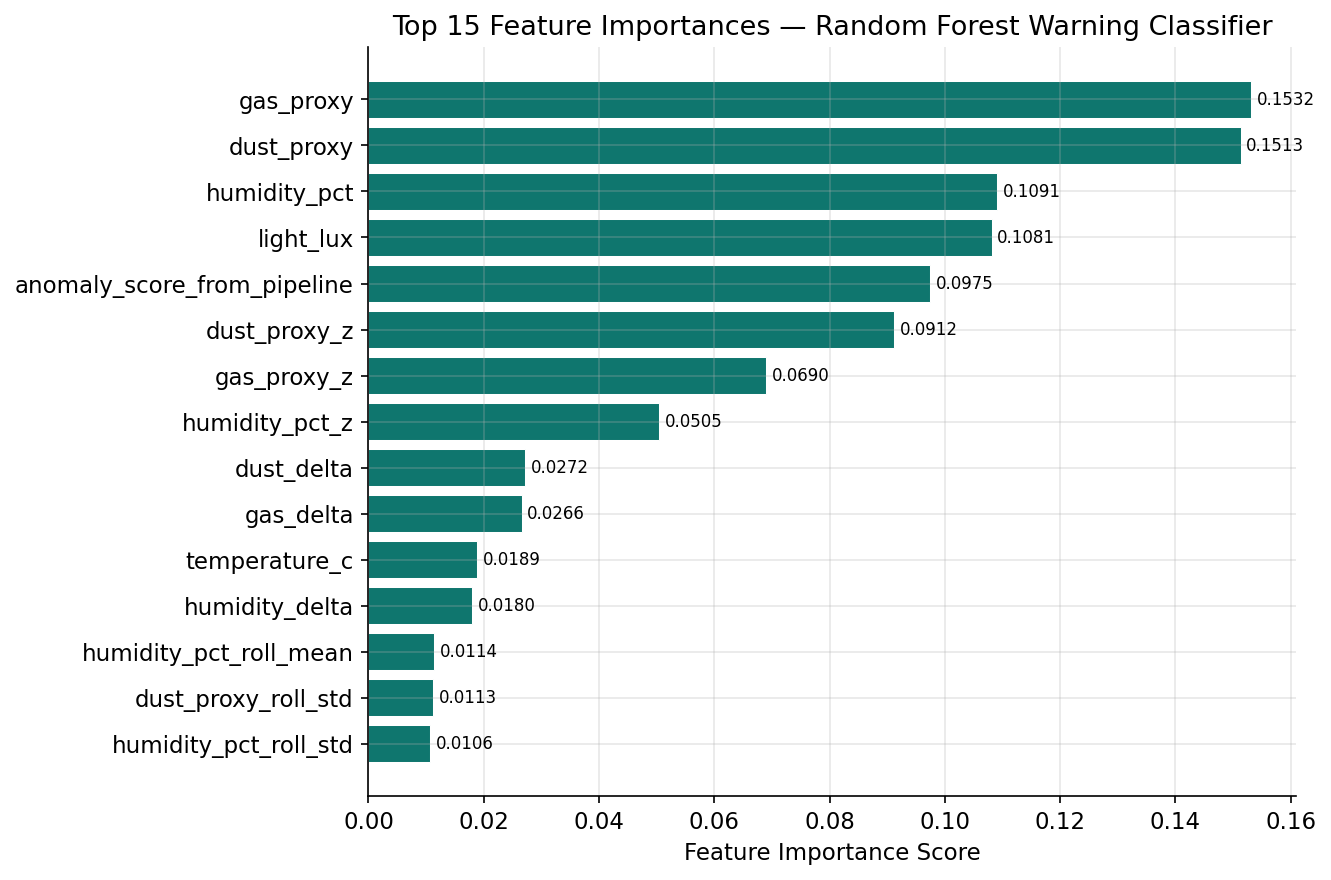

Saved: chart5c_feature_importance.png


In [16]:
# CHART 5c — Feature Importance (top 15)
importances = rf.feature_importances_
feat_df = pd.DataFrame({'feature': wf_cols, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(feat_df['feature'], feat_df['importance'],
               color=PALETTE['teal'], edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, feat_df['importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
ax.set_xlabel('Feature Importance Score')
ax.set_title('Top 15 Feature Importances — Random Forest Warning Classifier')
plt.tight_layout()
plt.savefig('chart5c_feature_importance.png')
plt.show()
print('Saved: chart5c_feature_importance.png')

---
## CHART 6 : Temporal Trend: Humidity by Hour of Day

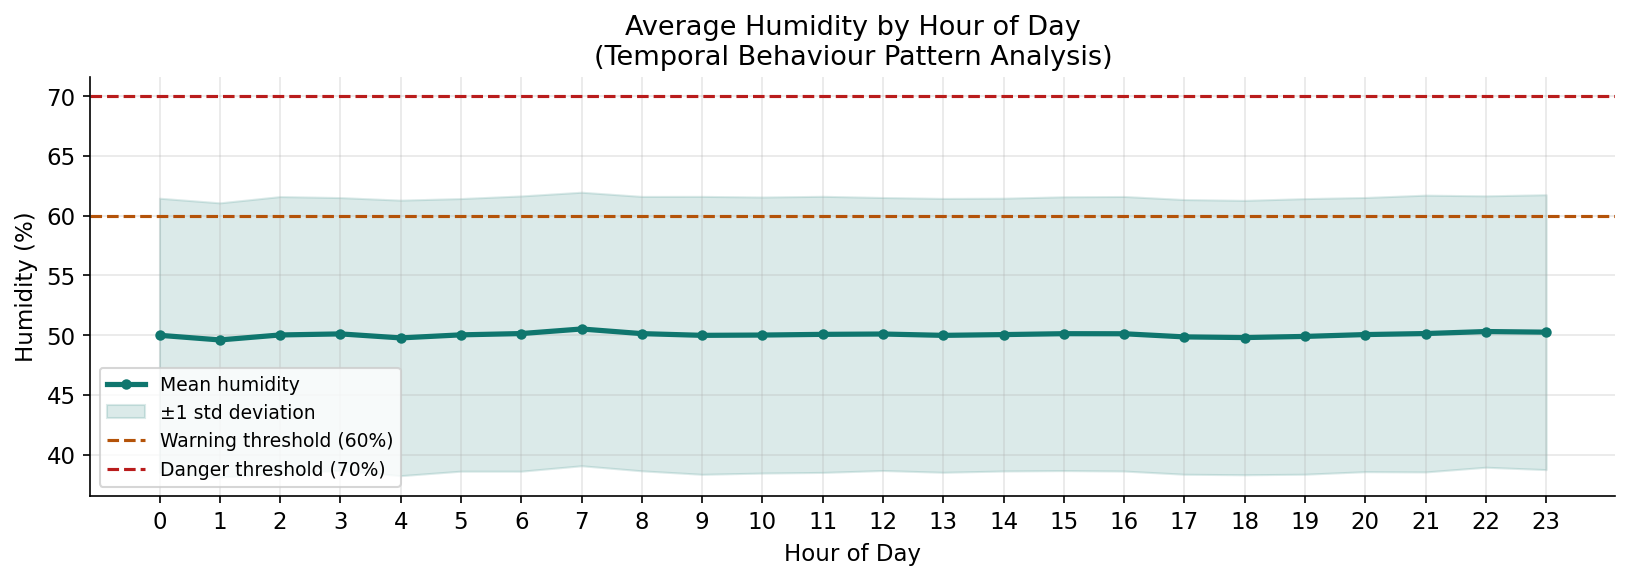

Saved: chart6_humidity_by_hour.png


In [17]:
hourly = df_clean.groupby('hour_of_day')['humidity_pct'].agg(['mean','std']).reset_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(hourly['hour_of_day'], hourly['mean'],
        color=PALETTE['teal'], linewidth=2.5, marker='o', markersize=4, label='Mean humidity')
ax.fill_between(
    hourly['hour_of_day'],
    hourly['mean'] - hourly['std'],
    hourly['mean'] + hourly['std'],
    alpha=0.15, color=PALETTE['teal'], label='±1 std deviation'
)
ax.axhline(60, color=PALETTE['amber'], linestyle='--', linewidth=1.5, label='Warning threshold (60%)')
ax.axhline(70, color=PALETTE['red'],   linestyle='--', linewidth=1.5, label='Danger threshold (70%)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Humidity (%)')
ax.set_title('Average Humidity by Hour of Day\n(Temporal Behaviour Pattern Analysis)')
ax.set_xticks(range(0, 24))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('chart6_humidity_by_hour.png')
plt.show()
print('Saved: chart6_humidity_by_hour.png')

---
## CHART 7 : Rolling Standard Deviation Over Time (Volatility)

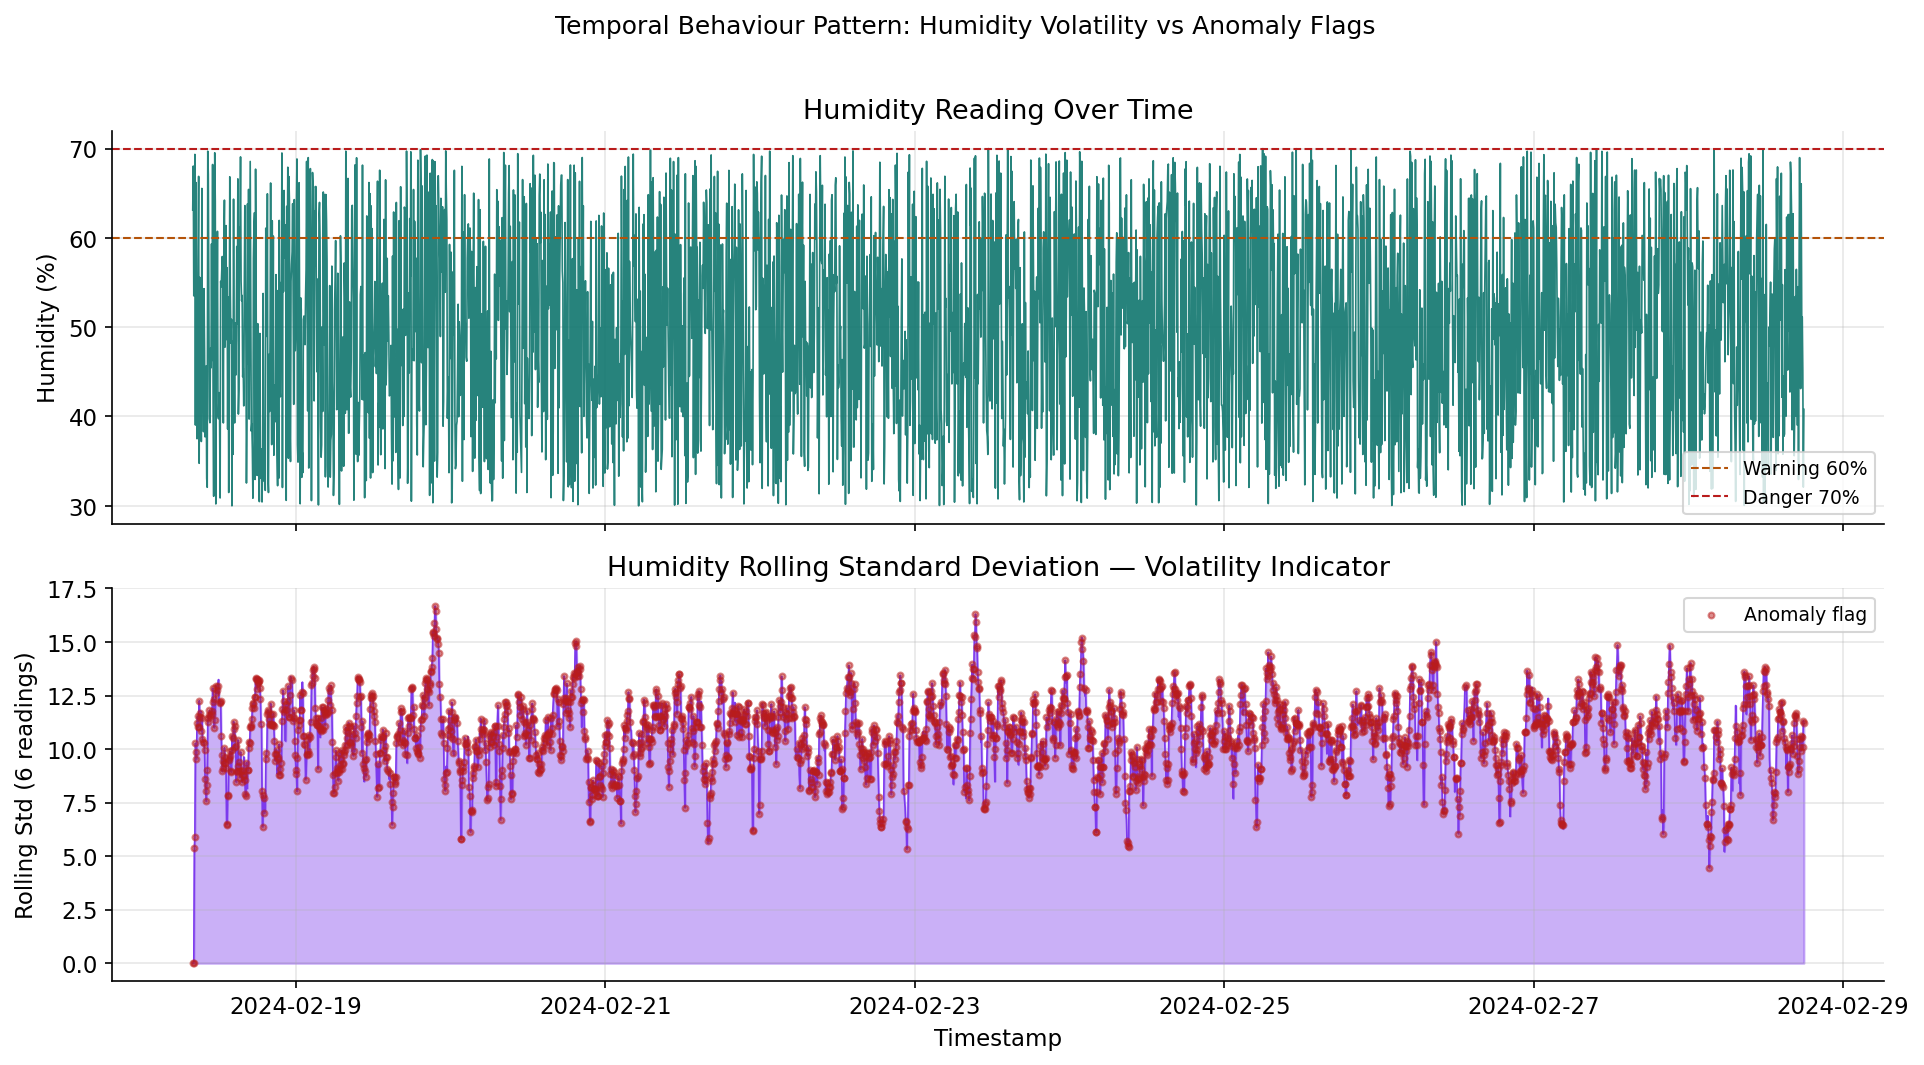

Saved: chart7_rolling_std_over_time.png


In [18]:
sample = df_clean[['timestamp','humidity_pct','humidity_pct_roll_std','anomaly_label']].dropna().head(3000)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(sample['timestamp'], sample['humidity_pct'],
             color=PALETTE['teal'], linewidth=0.8, alpha=0.9)
axes[0].axhline(60, color=PALETTE['amber'], linestyle='--', linewidth=1, label='Warning 60%')
axes[0].axhline(70, color=PALETTE['red'],   linestyle='--', linewidth=1, label='Danger 70%')
axes[0].set_ylabel('Humidity (%)')
axes[0].set_title('Humidity Reading Over Time')
axes[0].legend(fontsize=9)

anomaly_mask = sample['anomaly_label'] == 1
axes[1].fill_between(sample['timestamp'], sample['humidity_pct_roll_std'],
                     alpha=0.4, color=PALETTE['purple'])
axes[1].plot(sample['timestamp'], sample['humidity_pct_roll_std'],
             color=PALETTE['purple'], linewidth=0.8)
axes[1].scatter(
    sample['timestamp'][anomaly_mask],
    sample['humidity_pct_roll_std'][anomaly_mask],
    color=PALETTE['red'], s=8, alpha=0.5, label='Anomaly flag', zorder=5
)
axes[1].set_ylabel('Rolling Std (6 readings)')
axes[1].set_xlabel('Timestamp')
axes[1].set_title('Humidity Rolling Standard Deviation — Volatility Indicator')
axes[1].legend(fontsize=9)

plt.suptitle('Temporal Behaviour Pattern: Humidity Volatility vs Anomaly Flags', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('chart7_rolling_std_over_time.png')
plt.show()
print('Saved: chart7_rolling_std_over_time.png')

---
## CHART 8 : Correlation: Sensor Signals vs Warning Level

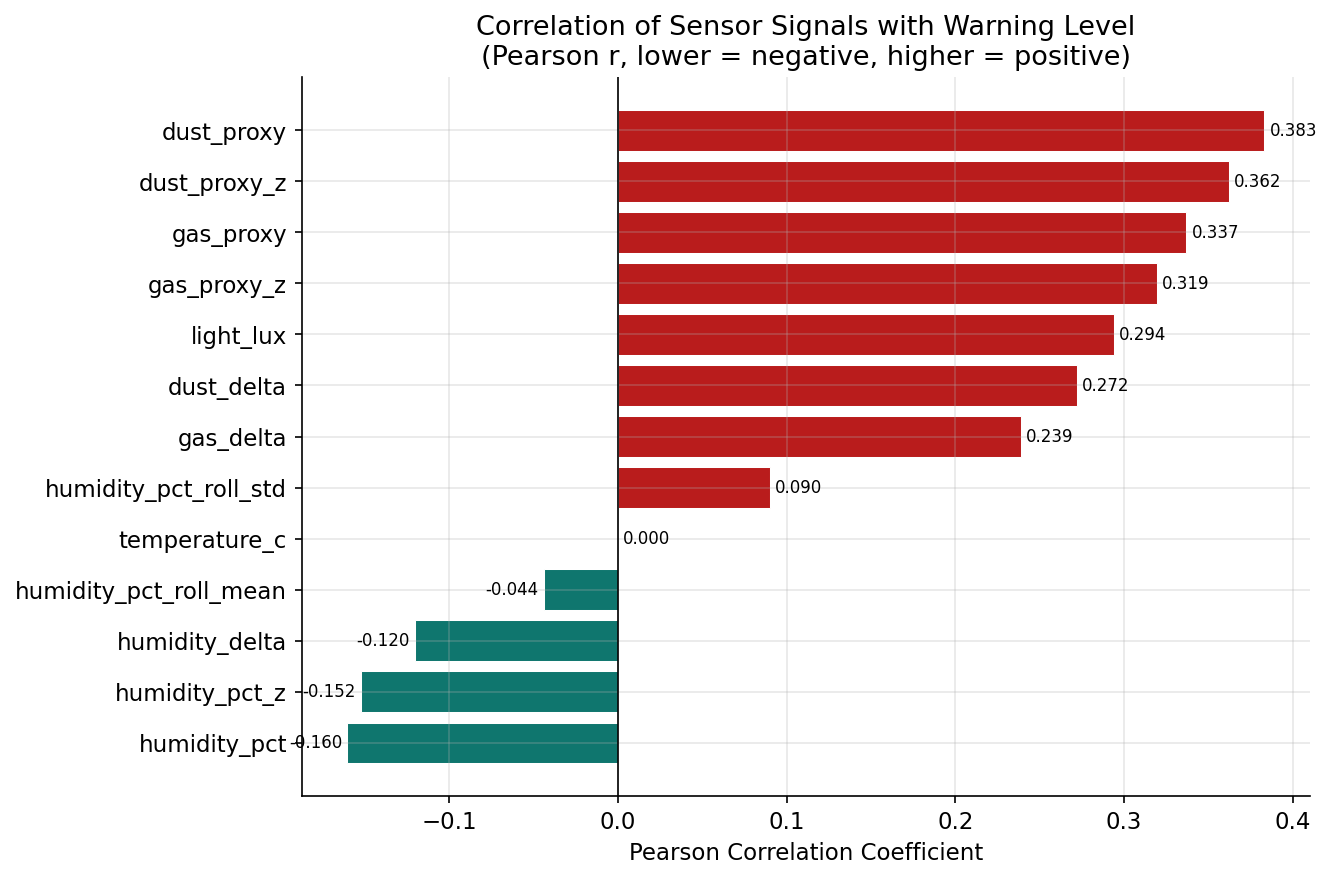

Saved: chart8_correlation_warning_level.png


In [19]:
signal_cols = [
    'temperature_c','humidity_pct','light_lux','dust_proxy','gas_proxy',
    'humidity_delta','dust_delta','gas_delta',
    'humidity_pct_z','dust_proxy_z','gas_proxy_z',
    'humidity_pct_roll_mean','humidity_pct_roll_std'
]
existing = [c for c in signal_cols if c in df_clean.columns]
corr_wl = df_clean[existing + ['warning_level_num']].corr()['warning_level_num'].drop('warning_level_num')
corr_wl = corr_wl.sort_values()

colors = [PALETTE['red'] if v > 0 else PALETTE['teal'] for v in corr_wl.values]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(corr_wl.index, corr_wl.values, color=colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, corr_wl.values):
    xpos = bar.get_width() + 0.003 if val >= 0 else bar.get_width() - 0.003
    ha = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', ha=ha, fontsize=8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation Coefficient')
ax.set_title('Correlation of Sensor Signals with Warning Level\n(Pearson r, lower = negative, higher = positive)')
plt.tight_layout()
plt.savefig('chart8_correlation_warning_level.png')
plt.show()
print('Saved: chart8_correlation_warning_level.png')